# 2. Multiple linear regression: OLS(Ordinary Least Square)

In [2]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**step 1: make 3d dataset with 2 input columns and 1 output column:**

In [3]:
x,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [4]:
df = pd.DataFrame({"feature1": x[:,0], "feature2": x[:,1], "target":y})
df.shape

(100, 3)

In [5]:
df.head()

,feature1,feature2,target
0,0.870884,-0.117493,-33.112029
1,0.518704,0.512813,27.582813
2,1.238124,-0.143631,-83.777849
3,-0.752855,-0.744936,-26.827931
4,-1.378080,0.592865,32.929026


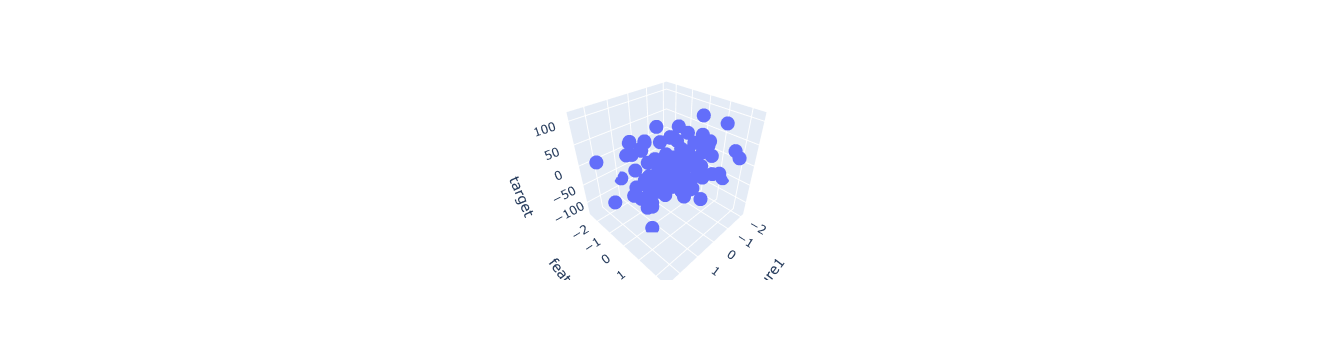

In [6]:
fig = px.scatter_3d(df, x="feature1", y="feature2", z="target")
fig.show()

**step2: now apply linear regression same as previous in simple LR:**

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=3)   # as now dimensin is 3 so random state is also 3

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()     # make object
lr.fit(x_train, y_train)    #train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[14.98,26.46]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.972
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[9.94,7.56]"


In [9]:
y_pred = lr.predict(x_test)
y_pred

array([-70.67698605, -10.22319152, -39.88818518, -62.50625347,
        11.03413666,  12.85820679,  28.36451247, -58.38507488,
       -17.32990896, -54.284768  ,  27.34486556, -15.37408094,
        35.59713371,  26.69618323, -11.68738982,  33.3056855 ,
       -81.51296526, -19.70302547, -49.27614935, -41.58091362])

In [10]:
print("MAE is :", mean_absolute_error(y_test, y_pred))
print("MSE is :", mean_squared_error(y_test, y_pred))
print("RMSE is :", np.sqrt(mean_absolute_error(y_test, y_pred)))
print("R2 score is :", r2_score(y_test, y_pred))

MAE is : 35.24918730672441
MSE is : 1691.739506056425
RMSE is : 5.937102602004146
R2 score is : 0.5376110449080322


In [11]:
# what linear regression are actually doing:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xgrid, ygrid = np.meshgrid(x, y)

# Create final first
final = np.vstack([xgrid.ravel(),ygrid.ravel()]).T

# Now predict
z_final = lr.predict(final).reshape(10, 10)

z = z_final

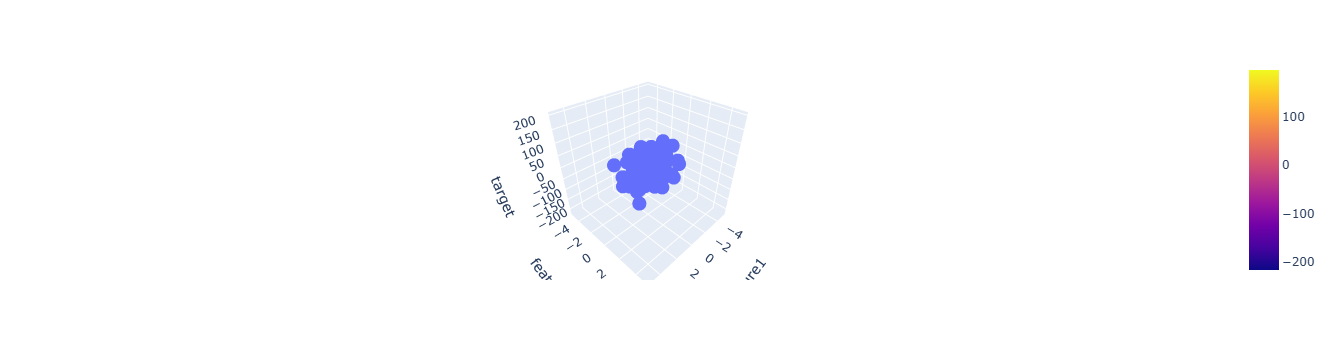

In [12]:
fig = px.scatter_3d(df, x="feature1", y="feature2", z="target")
fig.add_trace(go.Surface(x=x, y=y, z=z))
fig.show()

In [13]:
lr.coef_           # 2 values aa rhi as 3d data so plane with coefficient ie. beta1 and beta2

array([14.9780069 , 26.46209057])

In [14]:
lr.intercept_     # single value i.e. beta0

np.float64(-9.972135583774303)

# Practical use of multiple LR in real dataset:

**Step1: load dataset from sklearn library named diabetes**

In [15]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

x = data.data
y = data.target

print(x.shape)      # 10 input columns so 11 beta coefficients honge including constant beta0
print(y.shape)

(442, 10)
(442,)


In [16]:
x

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [17]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

**STEP2: now apply multiple LR**

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [19]:
print(x_train.shape)
print(x_test.shape)

(353, 10)
(89, 10)


In [20]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()     # make object

In [21]:
#train model now:

reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [22]:
y_pred = reg.predict(x_test)

In [23]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.43993386615689667

In [24]:
reg.coef_       # saare coefficients ki values except beta0 which is y intercept

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [26]:
reg.intercept_      # value of beta0 which is y intercept

np.float64(151.88331005254167)

# Now make our own linear regression class from scratch by using general formulas:
**and run on same data and compare ki hamara result same aarha hai yn nhi**

In [33]:
class MeraLr:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_train, y_train):                  # fit function to train model
        # vo equation:1 nikalne se pehle saare beta0 ko baahar nikaalte time matrix me 1 aaya tha na vo insert krna hai x_train ki matrix mein axis =1 means every row mein yeh operation perform krna hai
        x_train = np.insert(x_train,0,1,axis=1)     # x_train ke 0th col mein 1 add kiya 

        # calculate the coefficients: using final equation
        betas = np.linalg.inv(np.dot(x_train.T, x_train)).dot(x_train.T).dot(y_train)
        self.intercept_ = betas[0]    # as beta0 is intercept and first column so 0 index
        self.coef_ = betas[1:]        # rest all 

    def predict(self, x_test):
        y_pred = np.dot(x_test, self.coef_) + self.intercept_    # equation of hyperplane passing that points 
        return y_pred

In [34]:
lr = MeraLr()   # object banadiya

In [36]:
lr.fit(x_train, y_train)

In [37]:
x_train.shape

(353, 10)

In [38]:
np.insert(x_train,0,1, axis=1).shape

(353, 11)

In [40]:
y_pred = lr.predict(x_test)
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [41]:
r2_score(y_test,y_pred)

0.43993386615689656

**now compare it with above r2 score which we use using sklearn library and we find that they are same means our class perform same function as sklearn library**

In [42]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [43]:
lr.intercept_

np.float64(151.88331005254167)